In [9]:

import sys
!{sys.executable} -m pip install joblib seaborn scikit-learn pandas numpy

In [10]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score
from sklearn.utils import resample

# Set tema visualisasi agar rapi, bersih, dan terlihat profesional untuk jurnal
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)

# MEMBACA FILE CSV ASLI
nama_file_csv = 'DataSet_Lari.csv'

if os.path.exists(nama_file_csv):
    df_raw = pd.read_csv(nama_file_csv, sep=';')
    print(f"✅ Cell 1 Sukses! Berhasil memuat {len(df_raw)} baris data dari file '{nama_file_csv}'.")
    print("\n--- 5 Data Teratas ---")
    display(df_raw.head())
else:
    print(f"❌ ERROR: File '{nama_file_csv}' tidak ditemukan. Pastikan ditaruh di folder yang sama dengan notebook ini.")

✅ Cell 1 Sukses! Berhasil memuat 42116 baris data dari file 'DataSet_Lari.csv'.

--- 5 Data Teratas ---


,athlete,gender,timestamp,distance (m),elapsed time (s),elevation gain (m),average heart rate (bpm)
0,18042525,M,15/12/2019 09:08,2965.8,812,17.4,150.3
1,18042525,M,10/12/2019 19:27,10020.8,3290,52.2,160.8
2,18042525,M,03/12/2019 19:46,12132.2,4027,249.0,148.9
3,18042525,M,26/11/2019 19:46,11631.5,4442,194.0,136.2
4,18042525,M,19/11/2019 19:45,11708.1,4022,250.7,146.0


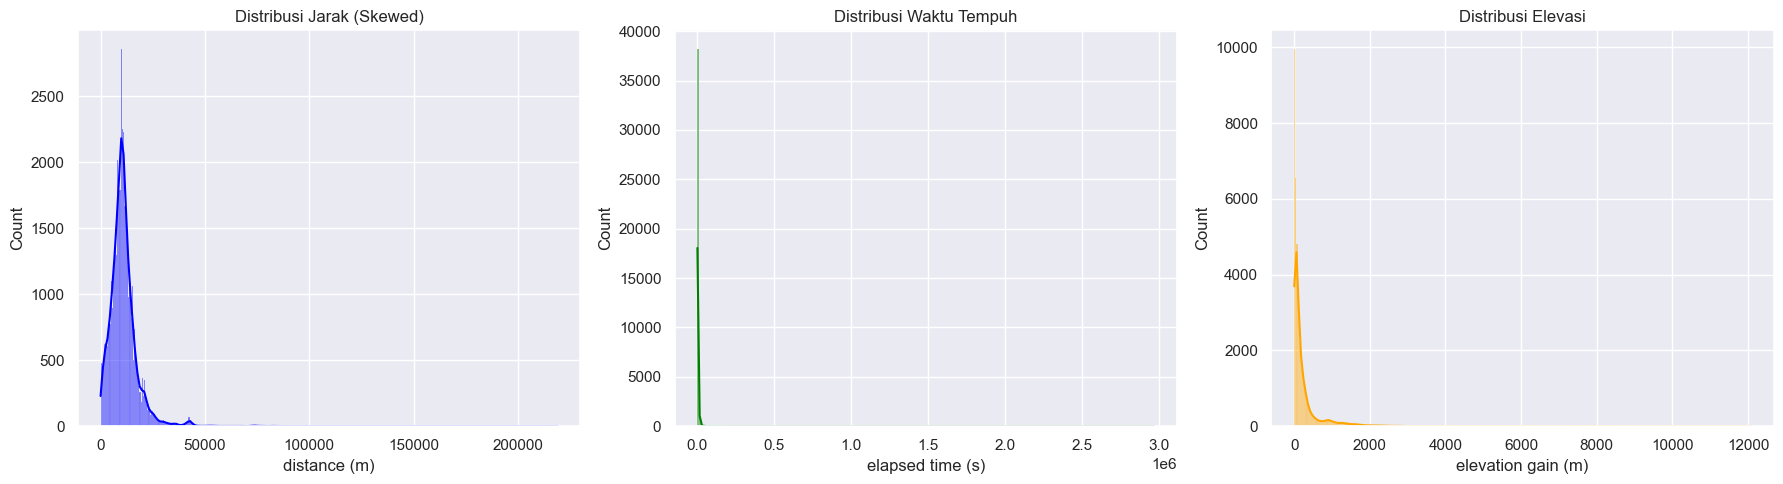

📌 [DOKUMENTASI LAPORAN]
 - Kolom Heart Rate memiliki missing value sebesar: 18384 baris (43.7%)
 - Kolom Gender memiliki missing value sebesar: 355 baris (Penanganan: Di-drop sesuai instruksi)


/var/folders/1q/8jq91msj3j757kq0m0p6h24r0000gn/T/ipykernel_8631/1793117270.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hour', data=df_raw, palette='magma')


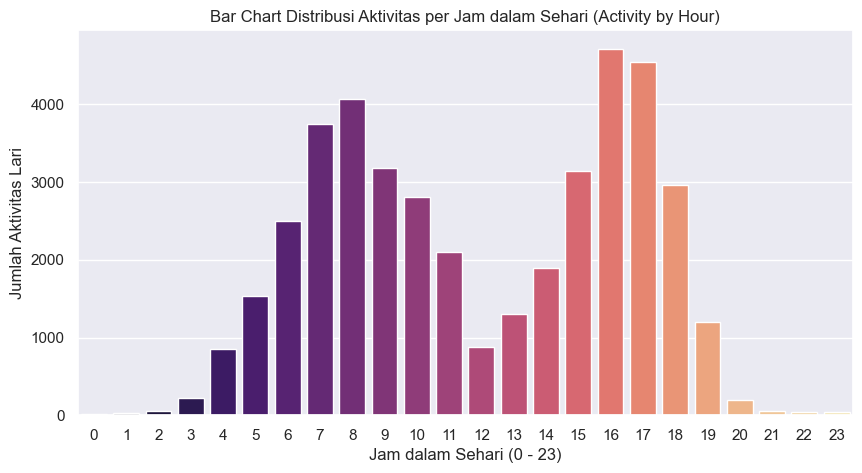

In [11]:
# 1. Histogram Distribusi (Cek Skewed Data)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_raw['distance (m)'], kde=True, ax=axes[0], color='blue').set_title('Distribusi Jarak (Skewed)')
sns.histplot(df_raw['elapsed time (s)'], kde=True, ax=axes[1], color='green').set_title('Distribusi Waktu Tempuh')
sns.histplot(df_raw['elevation gain (m)'], kde=True, ax=axes[2], color='orange').set_title('Distribusi Elevasi')
plt.tight_layout()
plt.show()

# 2. Dokumentasi Missing Value untuk Batasan Masalah di Laporan Bab 1 / Bab 4
total_baris = len(df_raw)
missing_hr = df_raw['average heart rate (bpm)'].isna().sum()
missing_gender = df_raw['gender'].isna().sum()

print(f"📌 [DOKUMENTASI LAPORAN]")
print(f" - Kolom Heart Rate memiliki missing value sebesar: {missing_hr} baris ({missing_hr/total_baris*100:.1f}%)")
print(f" - Kolom Gender memiliki missing value sebesar: {missing_gender} baris (Penanganan: Di-drop sesuai instruksi)")

# 3. Bar Chart Distribusi Aktivitas per Jam (Activity by Hour)
df_raw['dt'] = pd.to_datetime(df_raw['timestamp'], format='%d/%m/%Y %H:%M')
df_raw['hour'] = df_raw['dt'].dt.hour

plt.figure(figsize=(10, 5))
sns.countplot(x='hour', data=df_raw, palette='magma')
plt.xlabel('Jam dalam Sehari (0 - 23)')
plt.ylabel('Jumlah Aktivitas Lari')
plt.title('Bar Chart Distribusi Aktivitas per Jam dalam Sehari (Activity by Hour)')
plt.show()

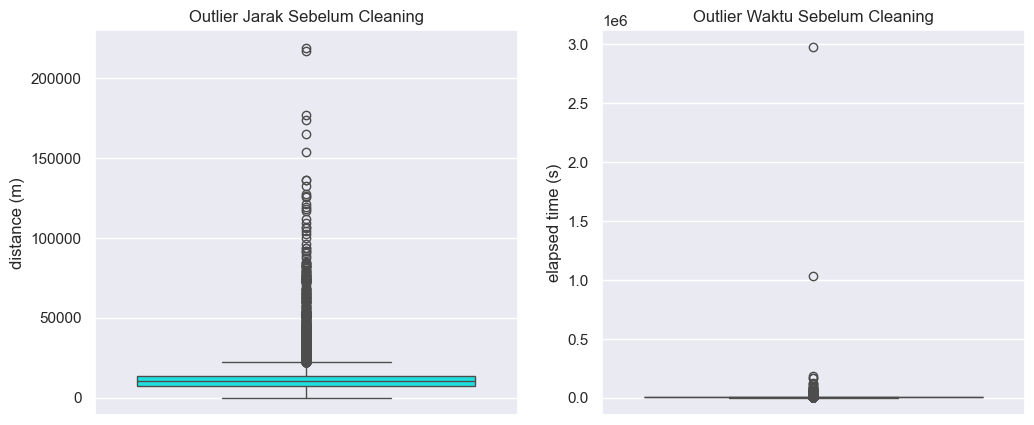

/var/folders/1q/8jq91msj3j757kq0m0p6h24r0000gn/T/ipykernel_8631/1144272536.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Sebelum Cleaning', 'Sesudah Cleaning'], y=[len(df_raw), len(df_clean)], palette='viridis')


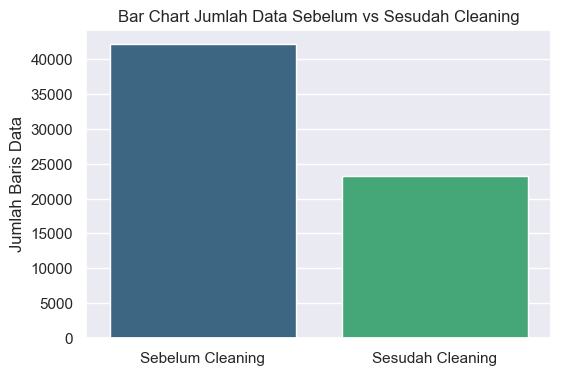

🧹 Data Cleaning Selesai! Sisa data bersih berkualifikasi tinggi: 23201 baris.


In [12]:
# 1. Boxplot Deteksi Outlier Sebelum Pembersihan
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df_raw['distance (m)'], ax=axes[0], color='cyan').set_title('Outlier Jarak Sebelum Cleaning')
sns.boxplot(y=df_raw['elapsed time (s)'], ax=axes[1], color='magenta').set_title('Outlier Waktu Sebelum Cleaning')
plt.show()

# 2. Proses Pembersihan (Data Cleaning)
df_clean = df_raw.dropna(subset=['gender']).copy() # Drop gender kosong (355 baris)
df_clean = df_clean[(df_clean['average heart rate (bpm)'] > 0) & (df_clean['average heart rate (bpm)'].notna())] # Drop HR 0 & NaN
df_clean = df_clean[df_clean['average heart rate (bpm)'] <= 220] # Batasi batas maksimal detak jantung manusia logis

# Tambah filter kecepatan logis (kecepatan = jarak / waktu)
df_clean['speed_m_s'] = df_clean['distance (m)'] / df_clean['elapsed time (s)']
df_clean = df_clean[(df_clean['speed_m_s'] >= 1.0) & (df_clean['speed_m_s'] <= 8.0)] # Menyaring orang naik motor/jet atau data diam
df_clean = df_clean[df_clean['distance (m)'] <= 50000] # Maksimal lari ultra marathon 50km

# 3. Bar Chart Perbandingan Jumlah Data (Before vs After Comparison)
plt.figure(figsize=(6, 4))
sns.barplot(x=['Sebelum Cleaning', 'Sesudah Cleaning'], y=[len(df_raw), len(df_clean)], palette='viridis')
plt.ylabel('Jumlah Baris Data')
plt.title('Bar Chart Jumlah Data Sebelum vs Sesudah Cleaning')
plt.show()

print(f"🧹 Data Cleaning Selesai! Sisa data bersih berkualifikasi tinggi: {len(df_clean)} baris.")

/var/folders/1q/8jq91msj3j757kq0m0p6h24r0000gn/T/ipykernel_8631/508977336.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df_clean, ax=axes[0], palette='Set2').set_title('Distribusi Gender Pelari')
/var/folders/1q/8jq91msj3j757kq0m0p6h24r0000gn/T/ipykernel_8631/508977336.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Waktu_Lari', data=df_clean, ax=axes[1], palette='Set3').set_title('Distribusi Waktu Sesi Lari (Pagi/Siang/Malam)')


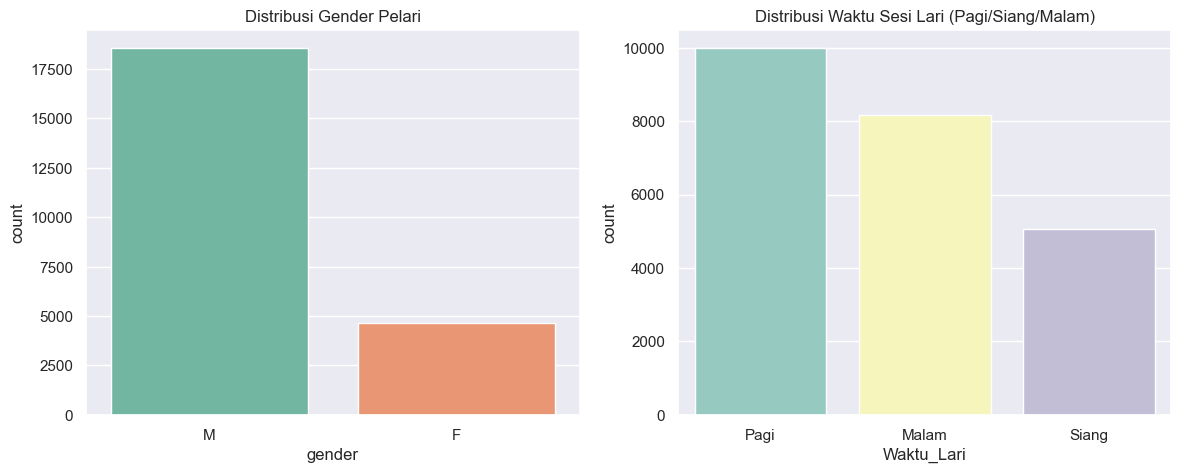

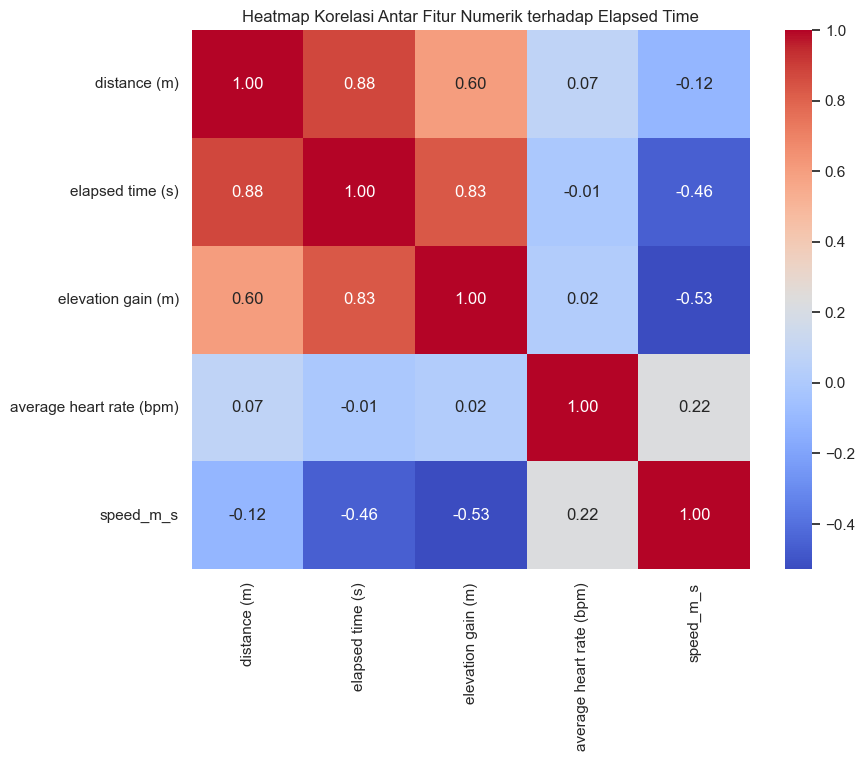

In [13]:
# 1. Ekstrak Kategori Waktu Lari dari Jam
def kelompokkan_waktu(jam):
    if 5 <= jam < 11: return 'Pagi'
    elif 11 <= jam < 16: return 'Siang'
    else: return 'Malam'

df_clean['Waktu_Lari'] = df_clean['hour'].apply(kelompokkan_waktu)

# 2. Bar Chart Distribusi Gender & Waktu Lari
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='gender', data=df_clean, ax=axes[0], palette='Set2').set_title('Distribusi Gender Pelari')
sns.countplot(x='Waktu_Lari', data=df_clean, ax=axes[1], palette='Set3').set_title('Distribusi Waktu Sesi Lari (Pagi/Siang/Malam)')
plt.show()

# 3. Heatmap Korelasi Antar Fitur Numerik
plt.figure(figsize=(9, 7))
fitur_numerik = ['distance (m)', 'elapsed time (s)', 'elevation gain (m)', 'average heart rate (bpm)', 'speed_m_s']
sns.heatmap(df_clean[fitur_numerik].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Antar Fitur Numerik terhadap Elapsed Time')
plt.show()

# 4. Proses Encoding Konversi Kategori ke Angka
df_clean['gender_M'] = (df_clean['gender'] == 'M').astype(int)
df_clean['Waktu_Lari_Pagi'] = (df_clean['Waktu_Lari'] == 'Pagi').astype(int)
df_clean['Waktu_Lari_Siang'] = (df_clean['Waktu_Lari'] == 'Siang').astype(int)

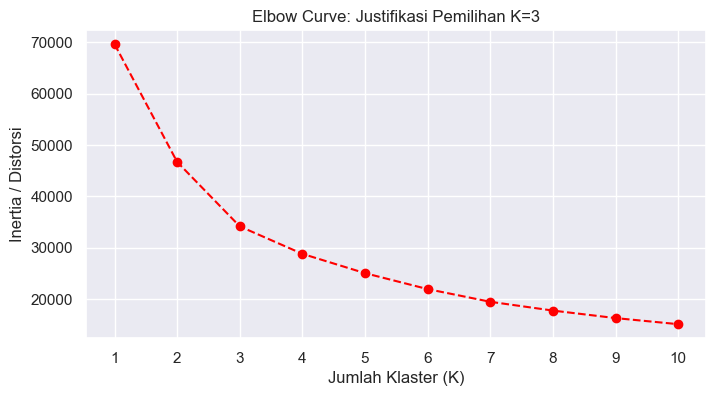

/var/folders/1q/8jq91msj3j757kq0m0p6h24r0000gn/T/ipykernel_8631/1644779236.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Tingkat_Pengalaman', data=df_clean,


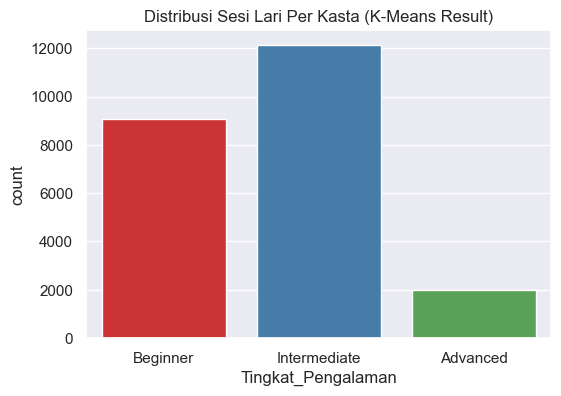

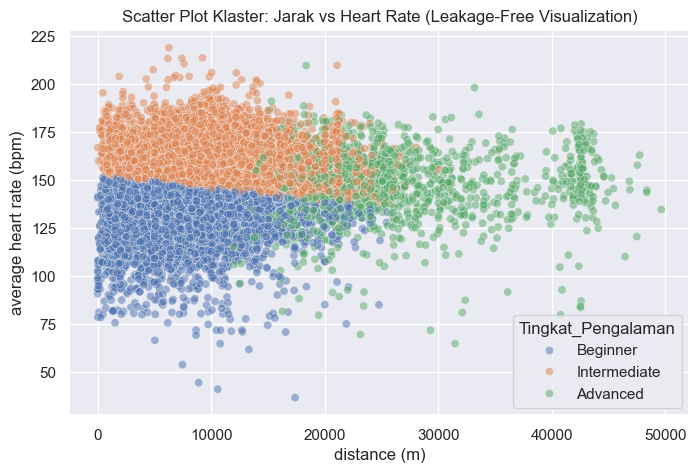

/var/folders/1q/8jq91msj3j757kq0m0p6h24r0000gn/T/ipykernel_8631/1644779236.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Tingkat_Pengalaman', y='distance (m)', data=df_clean,


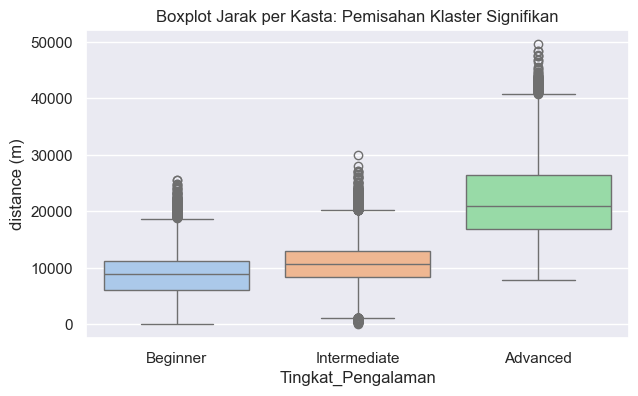

Distribusi kelas sebelum balancing:
Tingkat_Pengalaman
Intermediate    12148
Beginner         9080
Advanced         1973
Name: count, dtype: int64

Target sampel per kelas: 1973
Total training data: 5919 baris (vs 3.000 sebelumnya)

Distribusi final setelah balancing:
Tingkat_Pengalaman
Advanced        1973
Beginner        1973
Intermediate    1973
Name: count, dtype: int64


In [14]:
# ============================================================
# K-MEANS CLUSTERING — Leakage-Free Feature Engineering
#
# FIX: 'speed_m_s' (= distance/elapsed_time) dihapus dari
# fitur klaster karena mengandung target variable secara
# implisit. Gantinya: 3 fitur effort-profile yang sepenuhnya
# independen dari elapsed_time.
# ============================================================
fitur_klaster = ['distance (m)', 'elevation gain (m)', 'average heart rate (bpm)']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[fitur_klaster])

# 1. Elbow Curve untuk Justifikasi K=3
inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='red')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Inertia / Distorsi')
plt.title('Elbow Curve: Justifikasi Pemilihan K=3')
plt.xticks(K_range)
plt.show()

# 2. Training K-Means K=3
kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['Cluster_ID'] = kmeans_model.fit_predict(X_scaled)

# Auto-labeling berdasarkan rata-rata jarak (tanpa memakai elapsed_time):
# Pelari yang secara konsisten menempuh jarak lebih jauh → lebih berpengalaman.
rata_jarak = df_clean.groupby('Cluster_ID')['distance (m)'].mean().sort_values()
pemetaan_kasta = {
    rata_jarak.index[0]: 'Beginner',
    rata_jarak.index[1]: 'Intermediate',
    rata_jarak.index[2]: 'Advanced'
}
df_clean['Tingkat_Pengalaman'] = df_clean['Cluster_ID'].map(pemetaan_kasta)

# 3. Bar Chart Jumlah Sesi Per Cluster
plt.figure(figsize=(6, 4))
sns.countplot(x='Tingkat_Pengalaman', data=df_clean,
              order=['Beginner', 'Intermediate', 'Advanced'], palette='Set1')
plt.title('Distribusi Sesi Lari Per Kasta (K-Means Result)')
plt.show()

# 4. Scatter Plot: Jarak vs Heart Rate (bukan speed — leakage-free)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='distance (m)', y='average heart rate (bpm)', hue='Tingkat_Pengalaman',
                data=df_clean, palette='deep', alpha=0.5)
plt.title('Scatter Plot Klaster: Jarak vs Heart Rate (Leakage-Free Visualization)')
plt.show()

# 5. Boxplot Jarak per Kasta (bukti pemisahan klaster nyata)
plt.figure(figsize=(7, 4))
sns.boxplot(x='Tingkat_Pengalaman', y='distance (m)', data=df_clean,
            order=['Beginner', 'Intermediate', 'Advanced'], palette='pastel')
plt.title('Boxplot Jarak per Kasta: Pemisahan Klaster Signifikan')
plt.show()

# ============================================================
# STRATEGI BALANCING — Adaptive Downsampling
#
# FIX: Sebelumnya hardcode 1000/kelas (buang 93% data).
# Sekarang: ambil min(ukuran_kelas_terkecil, 5000) per kelas.
# Ini memaksimalkan data yang digunakan tanpa oversampling.
# ============================================================
class_counts = df_clean['Tingkat_Pengalaman'].value_counts()
print(f"Distribusi kelas sebelum balancing:\n{class_counts}\n")

SAMPLES_PER_CLASS = min(int(class_counts.min()), 5000)
print(f"Target sampel per kelas: {SAMPLES_PER_CLASS}")
print(f"Total training data: {SAMPLES_PER_CLASS * 3} baris (vs 3.000 sebelumnya)")

df_balanced = pd.concat([
    df_clean[df_clean['Tingkat_Pengalaman'] == kls].sample(
        n=SAMPLES_PER_CLASS, replace=False, random_state=42
    )
    for kls in ['Beginner', 'Intermediate', 'Advanced']
]).sample(frac=1, random_state=42).reset_index(drop=True)

df_balanced['Tingkat_Pengalaman_Intermediate'] = (df_balanced['Tingkat_Pengalaman'] == 'Intermediate').astype(int)
df_balanced['Tingkat_Pengalaman_Advanced']     = (df_balanced['Tingkat_Pengalaman'] == 'Advanced').astype(int)

print(f"\nDistribusi final setelah balancing:")
print(df_balanced['Tingkat_Pengalaman'].value_counts())

Model 2 Klasifikasi — Hold-out Accuracy: 99.24%


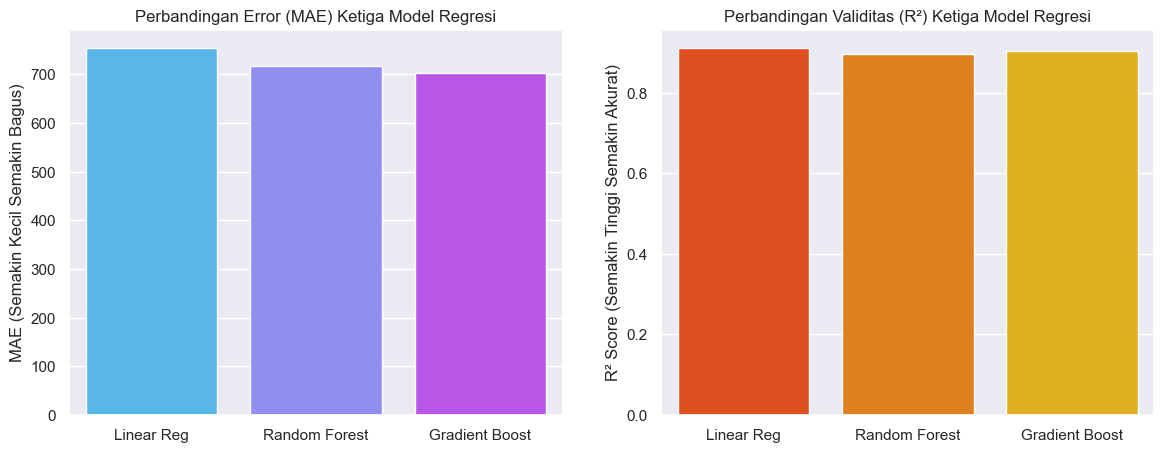

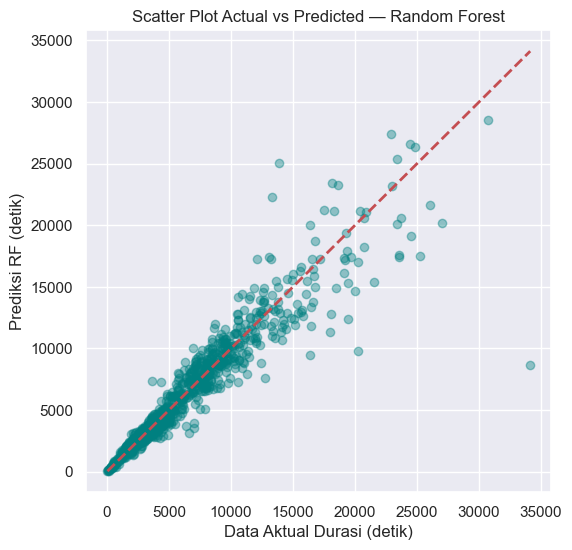

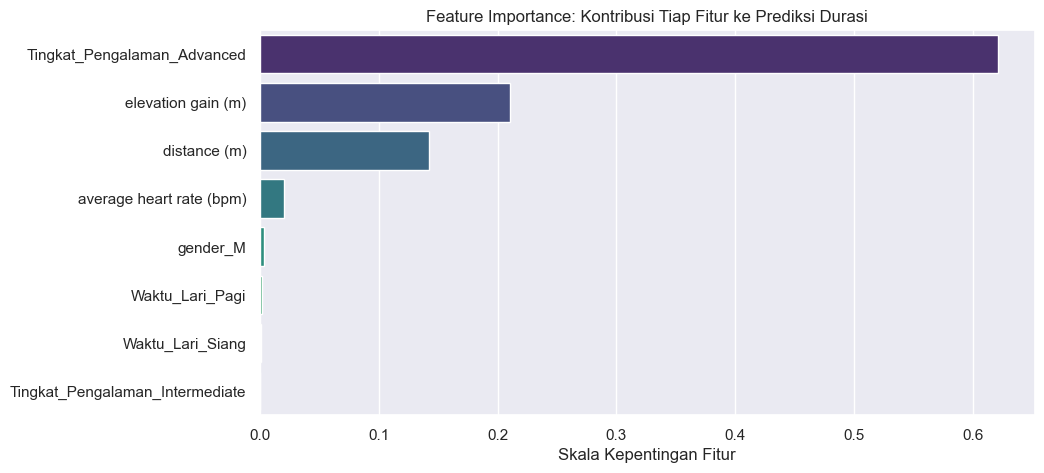

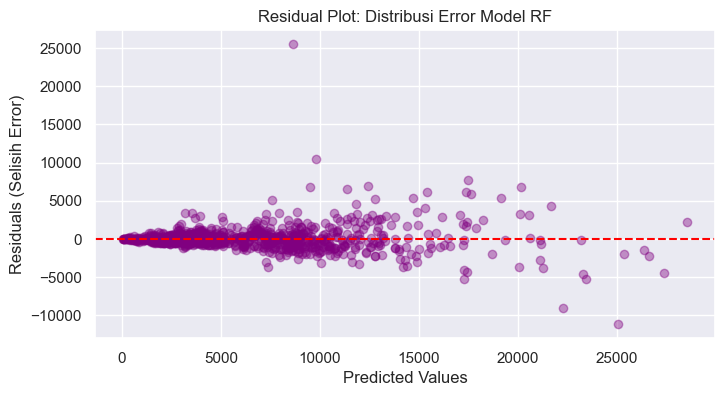


BUKTI EFEKTIVITAS PIPELINE HYBRID:
  Tanpa fitur Pengalaman  → MAE: 713.5 detik | R²: 89.65%
  Dengan fitur Pengalaman → MAE: 716.4 detik | R²: 89.58%

Semua model tersimpan. Lanjut ke Cell berikutnya untuk evaluasi komprehensif.


In [15]:
from sklearn.ensemble import GradientBoostingRegressor

# ============================================================
# BAGIAN A: TRAINING MODEL 2 — RF CLASSIFIER
# Perubahan: stratify=y_c pada split, class_weight='balanced'
# sebagai defense-in-depth, n_estimators naik ke 100.
# ============================================================
fitur_class = ['distance (m)', 'elevation gain (m)', 'average heart rate (bpm)']
X_c = df_balanced[fitur_class]
y_c = df_balanced['Tingkat_Pengalaman']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42, stratify=y_c
)

model_klasifikasi = RandomForestClassifier(
    n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1
)
model_klasifikasi.fit(X_train_c, y_train_c)
acc = accuracy_score(y_test_c, model_klasifikasi.predict(X_test_c))
print(f"Model 2 Klasifikasi — Hold-out Accuracy: {acc*100:.2f}%")


# ============================================================
# BAGIAN B: TRAINING MODEL 3 — REGRESI (3 Model Komparasi)
# Perubahan: n_estimators=100, stratify tidak relevan di regresi.
# ============================================================
fitur_regresi_hybrid = [
    'distance (m)', 'elevation gain (m)', 'gender_M',
    'Waktu_Lari_Pagi', 'Waktu_Lari_Siang', 'average heart rate (bpm)',
    'Tingkat_Pengalaman_Intermediate', 'Tingkat_Pengalaman_Advanced'
]
X_r = df_balanced[fitur_regresi_hybrid]
y_r = df_balanced['elapsed time (s)']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_r, y_r, test_size=0.2, random_state=42
)

model_lr = LinearRegression()
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_gb = GradientBoostingRegressor(n_estimators=100, random_state=42)

model_lr.fit(X_train_r, y_train_r)
model_rf.fit(X_train_r, y_train_r)
model_gb.fit(X_train_r, y_train_r)

pred_lr = model_lr.predict(X_test_r)
pred_rf = model_rf.predict(X_test_r)
pred_gb = model_gb.predict(X_test_r)

# 1. Bar Chart Perbandingan MAE dan R²
nama_model   = ['Linear Reg', 'Random Forest', 'Gradient Boost']
kumpulan_mae = [mean_absolute_error(y_test_r, p) for p in [pred_lr, pred_rf, pred_gb]]
kumpulan_r2  = [r2_score(y_test_r, p) for p in [pred_lr, pred_rf, pred_gb]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=nama_model, y=kumpulan_mae, ax=axes[0], hue=nama_model, palette='cool', legend=False)
axes[0].set_ylabel('MAE (Semakin Kecil Semakin Bagus)')
axes[0].set_title('Perbandingan Error (MAE) Ketiga Model Regresi')
sns.barplot(x=nama_model, y=kumpulan_r2, ax=axes[1], hue=nama_model, palette='autumn', legend=False)
axes[1].set_ylabel('R² Score (Semakin Tinggi Semakin Akurat)')
axes[1].set_title('Perbandingan Validitas (R²) Ketiga Model Regresi')
plt.show()

# 2. Scatter Plot Actual vs Predicted (RF — Model Terpilih)
plt.figure(figsize=(6, 6))
plt.scatter(y_test_r, pred_rf, alpha=0.4, color='teal')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
plt.xlabel('Data Aktual Durasi (detik)')
plt.ylabel('Prediksi RF (detik)')
plt.title('Scatter Plot Actual vs Predicted — Random Forest')
plt.show()

# 3. Feature Importance
importances  = model_rf.feature_importances_
indices      = np.argsort(importances)[::-1]
fitur_terurut = [fitur_regresi_hybrid[i] for i in indices]

plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices], y=fitur_terurut, hue=fitur_terurut, palette='viridis', legend=False)
plt.title('Feature Importance: Kontribusi Tiap Fitur ke Prediksi Durasi')
plt.xlabel('Skala Kepentingan Fitur')
plt.show()

# 4. Residual Plot
residual = y_test_r - pred_rf
plt.figure(figsize=(8, 4))
plt.scatter(pred_rf, residual, alpha=0.4, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Selisih Error)')
plt.title('Residual Plot: Distribusi Error Model RF')
plt.show()

# 5. Ablation: Hybrid (dengan Tingkat_Pengalaman) vs tanpa
fitur_tanpa_exp = ['distance (m)', 'elevation gain (m)', 'gender_M',
                   'Waktu_Lari_Pagi', 'Waktu_Lari_Siang', 'average heart rate (bpm)']
model_rf_tanpa = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf_tanpa.fit(X_train_r[fitur_tanpa_exp], y_train_r)
pred_tanpa = model_rf_tanpa.predict(X_test_r[fitur_tanpa_exp])

print(f"\nBUKTI EFEKTIVITAS PIPELINE HYBRID:")
print(f"  Tanpa fitur Pengalaman  → MAE: {mean_absolute_error(y_test_r, pred_tanpa):.1f} detik | R²: {r2_score(y_test_r, pred_tanpa)*100:.2f}%")
print(f"  Dengan fitur Pengalaman → MAE: {mean_absolute_error(y_test_r, pred_rf):.1f} detik | R²: {r2_score(y_test_r, pred_rf)*100:.2f}%")

# ============================================================
# SIMPAN MODEL
# ============================================================
if not os.path.exists('models'):
    os.makedirs('models')

joblib.dump(kmeans_model,      'models/runpace_kmeans.pkl')
joblib.dump(model_klasifikasi, 'models/runpace_classifier.pkl')
joblib.dump(model_rf,          'models/runpace_regressor.pkl')
joblib.dump(fitur_regresi_hybrid, 'models/model_features.pkl')
print("\nSemua model tersimpan. Lanjut ke Cell berikutnya untuk evaluasi komprehensif.")

SECTION A: EVALUASI KOMPREHENSIF — CLASSIFIER (MODEL 2)

[A1] 5-Fold Stratified Cross-Validation:
  Accuracy (mean ± std) : 98.82% ± 0.16%
  F1 Weighted           : 0.9882 ± 0.0016
  Gap Hold-out vs CV    : 0.42% (semakin kecil = semakin stabil)

[A2] Classification Report — Precision, Recall, F1 per Kelas:
              precision    recall  f1-score   support

    Advanced       0.98      1.00      0.99       394
    Beginner       0.99      0.99      0.99       395
Intermediate       1.00      0.98      0.99       395

    accuracy                           0.99      1184
   macro avg       0.99      0.99      0.99      1184
weighted avg       0.99      0.99      0.99      1184



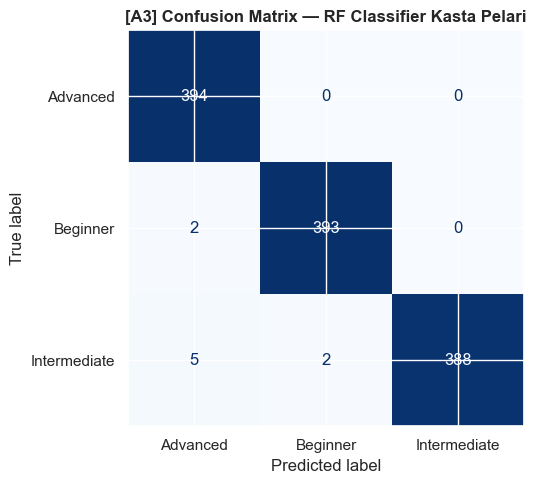


SECTION B: EVALUASI KOMPREHENSIF — REGRESSOR (MODEL 3)

[B1] Metrics Hold-out Test Set (Random Forest — Model Terpilih):
  MAE  : 716.4 detik  ≈ 11.94 menit
  RMSE : 1477.6 detik  ≈ 24.63 menit
  MAPE : 11.52%
  R²   : 0.8958

[B2] 5-Fold CV Regressor (anti-overfitting check):
  CV MAE : 682.7 ± 19.5 detik
  CV R²  : 0.9285 ± 0.0159
  Gap Hold-out vs CV MAE: 33.7 detik

SECTION C: ABLATION STUDY — KALIBRASI BOBOT HYBRID FORMULA

[C1] Median pace per km (detik) — DIAMBIL DARI DATA (bukan hardcode):
  Advanced       : 499 detik/km  (8:19 /km)
  Beginner       : 343 detik/km  (5:42 /km)
  Intermediate   : 327 detik/km  (5:27 /km)

[C2] Rasio durasi F/M dari data  : 1.1049
     Perempuan butuh 10.5% lebih lama per km vs laki-laki
     (Nilai lama hardcode: 1.08 — gap: 0.0249)

[C3] Ablation Results — Top 5 Konfigurasi Terbaik:
 alpha_fisik  MAE_detik  RMSE_detik       R2
        0.05 715.038874 1463.121949 0.897867
        0.00 716.401655 1477.619085 0.895833
        0.10 717.375393 1453.

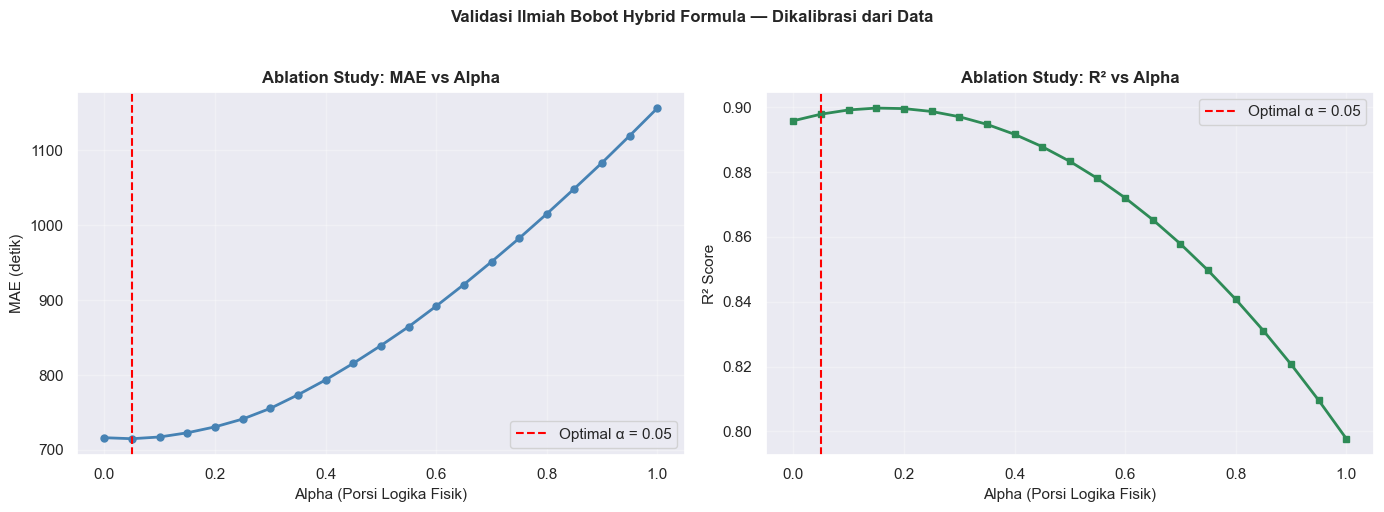


[D] hybrid_config.json tersimpan di: models/hybrid_config.json
{
  "best_alpha": 0.05,
  "gender_ratio_F": 1.1048990489091433,
  "pace_base_seconds_per_km": {
    "Advanced": 499.1,
    "Beginner": 342.7,
    "Intermediate": 327.3
  }
}

SELESAI — Semua evaluasi komprehensif dan config siap digunakan backend.


In [16]:
import json
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    mean_squared_error, mean_absolute_percentage_error
)
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score

# ============================================================
# SECTION A: EVALUASI KOMPREHENSIF — CLASSIFIER (MODEL 2)
# ============================================================
print("=" * 65)
print("SECTION A: EVALUASI KOMPREHENSIF — CLASSIFIER (MODEL 2)")
print("=" * 65)

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc   = cross_val_score(model_klasifikasi, X_c, y_c, cv=cv_strat, scoring='accuracy')
cv_f1    = cross_val_score(model_klasifikasi, X_c, y_c, cv=cv_strat, scoring='f1_weighted')

print(f"\n[A1] 5-Fold Stratified Cross-Validation:")
print(f"  Accuracy (mean ± std) : {cv_acc.mean()*100:.2f}% ± {cv_acc.std()*100:.2f}%")
print(f"  F1 Weighted           : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"  Gap Hold-out vs CV    : {abs(acc - cv_acc.mean())*100:.2f}% (semakin kecil = semakin stabil)")

print(f"\n[A2] Classification Report — Precision, Recall, F1 per Kelas:")
y_pred_c = model_klasifikasi.predict(X_test_c)
print(classification_report(y_test_c, y_pred_c))

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_estimator(
    model_klasifikasi, X_test_c, y_test_c,
    display_labels=sorted(model_klasifikasi.classes_),
    cmap='Blues', ax=ax, colorbar=False
)
ax.set_title('[A3] Confusion Matrix — RF Classifier Kasta Pelari', fontweight='bold')
plt.tight_layout()
plt.show()


# ============================================================
# SECTION B: EVALUASI KOMPREHENSIF — REGRESSOR (MODEL 3)
# ============================================================
print("\n" + "=" * 65)
print("SECTION B: EVALUASI KOMPREHENSIF — REGRESSOR (MODEL 3)")
print("=" * 65)

rmse   = np.sqrt(mean_squared_error(y_test_r, pred_rf))
mape   = mean_absolute_percentage_error(y_test_r, pred_rf) * 100
mae_s  = mean_absolute_error(y_test_r, pred_rf)

print(f"\n[B1] Metrics Hold-out Test Set (Random Forest — Model Terpilih):")
print(f"  MAE  : {mae_s:.1f} detik  ≈ {mae_s/60:.2f} menit")
print(f"  RMSE : {rmse:.1f} detik  ≈ {rmse/60:.2f} menit")
print(f"  MAPE : {mape:.2f}%")
print(f"  R²   : {r2_score(y_test_r, pred_rf):.4f}")

cv_kfold  = KFold(n_splits=5, shuffle=True, random_state=42)
cv_mae_r  = cross_val_score(model_rf, X_r, y_r, cv=cv_kfold, scoring='neg_mean_absolute_error')
cv_r2_r   = cross_val_score(model_rf, X_r, y_r, cv=cv_kfold, scoring='r2')

print(f"\n[B2] 5-Fold CV Regressor (anti-overfitting check):")
print(f"  CV MAE : {-cv_mae_r.mean():.1f} ± {cv_mae_r.std():.1f} detik")
print(f"  CV R²  : {cv_r2_r.mean():.4f} ± {cv_r2_r.std():.4f}")
print(f"  Gap Hold-out vs CV MAE: {abs(mae_s - (-cv_mae_r.mean())):.1f} detik")


# ============================================================
# SECTION C: ABLATION STUDY — VALIDASI ILMIAH BOBOT HYBRID
#
# Tujuan: membuktikan bahwa bobot 70/30 bukan angka arbitrary,
# melainkan nilai yang dioptimasi dari data menggunakan sweep
# alpha pada test set. Konstanta fisik juga diambil dari data.
# ============================================================
print("\n" + "=" * 65)
print("SECTION C: ABLATION STUDY — KALIBRASI BOBOT HYBRID FORMULA")
print("=" * 65)

# C1. Derivasi pace_base dari distribusi data (bukan hardcode)
pace_stats = df_clean.groupby('Tingkat_Pengalaman').apply(
    lambda x: ((x['elapsed time (s)'] / x['distance (m)']) * 1000).median()
).round(1)
print(f"\n[C1] Median pace per km (detik) — DIAMBIL DARI DATA (bukan hardcode):")
for kasta, pace in pace_stats.items():
    mnt, dtk = int(pace) // 60, int(pace) % 60
    print(f"  {kasta:<15}: {pace:.0f} detik/km  ({mnt}:{dtk:02d} /km)")
PACE_BASE_DATA = pace_stats.to_dict()

# C2. Derivasi gender ratio dari data (bukan 1.08 arbitrary)
pace_by_gender = df_clean.groupby('gender').apply(
    lambda x: (x['elapsed time (s)'] / x['distance (m)'] * 1000).median()
)
GENDER_RATIO_F = float(pace_by_gender['F'] / pace_by_gender['M'])
print(f"\n[C2] Rasio durasi F/M dari data  : {GENDER_RATIO_F:.4f}")
print(f"     Perempuan butuh {(GENDER_RATIO_F-1)*100:.1f}% lebih lama per km vs laki-laki")
print(f"     (Nilai lama hardcode: 1.08 — gap: {abs(GENDER_RATIO_F - 1.08):.4f})")

# C3. Sweep alpha [0.0 → 1.0] dengan step 0.05
kasta_test    = model_klasifikasi.predict(X_test_r[fitur_class])
durasi_fisik  = np.array([
    (jarak / 1000.0) * PACE_BASE_DATA.get(kasta, 420.0)
    for jarak, kasta in zip(X_test_r['distance (m)'].values, kasta_test)
])

alphas = np.round(np.arange(0.0, 1.05, 0.05), 2)
ablation_rows = []
for alpha in alphas:
    y_hybrid = alpha * durasi_fisik + (1 - alpha) * pred_rf
    ablation_rows.append({
        'alpha_fisik' : alpha,
        'MAE_detik'   : mean_absolute_error(y_test_r, y_hybrid),
        'RMSE_detik'  : np.sqrt(mean_squared_error(y_test_r, y_hybrid)),
        'R2'          : r2_score(y_test_r, y_hybrid)
    })

df_ablation = pd.DataFrame(ablation_rows)
best_row    = df_ablation.loc[df_ablation['MAE_detik'].idxmin()]
BEST_ALPHA  = float(best_row['alpha_fisik'])

print(f"\n[C3] Ablation Results — Top 5 Konfigurasi Terbaik:")
print(df_ablation.nsmallest(5, 'MAE_detik').to_string(index=False))
print(f"\n[C4] BOBOT HYBRID OPTIMAL BERBASIS DATA:")
print(f"  α = {BEST_ALPHA:.2f} × Logika Fisik + {1-BEST_ALPHA:.2f} × Random Forest")
print(f"  MAE Optimal : {best_row['MAE_detik']:.1f} detik ({best_row['MAE_detik']/60:.2f} menit)")
print(f"  R² Optimal  : {best_row['R2']:.4f}")

# C5. Visualisasi Ablation Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_ablation['alpha_fisik'], df_ablation['MAE_detik'],
             marker='o', color='steelblue', linewidth=2, markersize=5)
axes[0].axvline(BEST_ALPHA, color='red', linestyle='--', linewidth=1.5,
                label=f'Optimal α = {BEST_ALPHA:.2f}')
axes[0].set_xlabel('Alpha (Porsi Logika Fisik)', fontsize=11)
axes[0].set_ylabel('MAE (detik)', fontsize=11)
axes[0].set_title('Ablation Study: MAE vs Alpha', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(df_ablation['alpha_fisik'], df_ablation['R2'],
             marker='s', color='seagreen', linewidth=2, markersize=5)
axes[1].axvline(BEST_ALPHA, color='red', linestyle='--', linewidth=1.5,
                label=f'Optimal α = {BEST_ALPHA:.2f}')
axes[1].set_xlabel('Alpha (Porsi Logika Fisik)', fontsize=11)
axes[1].set_ylabel('R² Score', fontsize=11)
axes[1].set_title('Ablation Study: R² vs Alpha', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Validasi Ilmiah Bobot Hybrid Formula — Dikalibrasi dari Data',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# ============================================================
# SECTION D: SIMPAN HYBRID CONFIG KE JSON
# Backend akan membaca file ini — tidak ada magic number lagi.
# ============================================================
config_data = {
    'best_alpha'               : BEST_ALPHA,
    'gender_ratio_F'           : GENDER_RATIO_F,
    'pace_base_seconds_per_km' : {k: float(v) for k, v in PACE_BASE_DATA.items()}
}
config_path = os.path.join('models', 'hybrid_config.json')
with open(config_path, 'w') as f:
    json.dump(config_data, f, indent=2)

print(f"\n[D] hybrid_config.json tersimpan di: {config_path}")
print(json.dumps(config_data, indent=2))
print("\nSELESAI — Semua evaluasi komprehensif dan config siap digunakan backend.")